In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('cleaned_data.csv')

In [5]:
dir_df = df.copy()

In [6]:
dir_df["Released_Year"] = dir_df["Released_Year"].astype(int)

In [15]:
#director statistics
director_stats = (
    dir_df.groupby("Director")
          .agg(
              Film_Count=("Series_Title", "count"),
              Avg_Gross=("Gross", "mean"),
              Avg_Meta=("Meta_score", "mean")
          )
)

#director profile
def get_profile(row):
    if row["Avg_Gross"] >= 200_000_000:
        return "Elite"
    elif row["Film_Count"] >= 5 and row["Avg_Gross"] >= 50_000_000:
        return "High-Profile"
    elif row["Film_Count"] > 2:
        return "Established"
    else:
        return "Emerging"

director_stats["director_profile"] = director_stats.apply(get_profile, axis=1)

dir_df["director_profile"] = dir_df["Director"].map(
    director_stats["director_profile"]
)

In [16]:
# categorical mapping upfront and back end payments for directors

upfront_map = {
    "Emerging": {
        "Low": 15_000,
        "Moderate": 50_000,
        "High": 1_000_000,
        "Blockbuster": 2_000_000
    },
    "Established": {
        "Low": 50_000,
        "Moderate": 1_000_000,
        "High": 3_000_000,
        "Blockbuster": 5_000_000
    },
    "High-Profile": {
        "Low": 200_000,
        "Moderate": 2_000_000,
        "High": 5_000_000,
        "Blockbuster": 10_000_000
    },
    "Elite": {
        "Low": 1_000_000,
        "Moderate": 8_000_000,
        "High": 12_000_000,
        "Blockbuster": 20_000_000
    }
}

dir_df["upfront_deal"] = [
    upfront_map[p][g]
    for p, g in zip(dir_df["director_profile"], dir_df["gross_category"])
]

backend_map = {
    "Emerging": 0,
    "Established": 2,
    "High-Profile": 3,
    "Elite": 4
}

dir_df["backend_profit_pct"] = dir_df["director_profile"].map(backend_map)

dir_df["backend_profit"] = (
    dir_df["Gross"] * dir_df["backend_profit_pct"] / 100
)

In [17]:
#changing data types of the new 3 columns

dir_df[["upfront_deal", "backend_profit_pct", "backend_profit"]] = (
    dir_df[["upfront_deal", "backend_profit_pct", "backend_profit"]]
    .astype(int)
)

In [18]:
#dealing with extremely low gross results

low_gross = dir_df["Gross"] < 50_000

dir_df.loc[low_gross, "upfront_deal"] = 1_000
dir_df.loc[low_gross, "backend_profit_pct"] = 0
dir_df.loc[low_gross, "backend_profit"] = 0

bottom_5 = (
    dir_df.nsmallest(5, "Gross")
      .reset_index(drop=True)
)


bottom_5[[
    "Series_Title",
    "Gross",
    "upfront_deal",
    "backend_profit_pct",
    "backend_profit"
]]

,Series_Title,Gross,upfront_deal,backend_profit_pct,backend_profit
0,Adams æbler,1305,1000,0,0
1,Knockin' on Heaven's Door,3296,1000,0,0
2,Mr. Nobody,3600,1000,0,0
3,Dead Man's Shoes,6013,1000,0,0
4,Ajeossi,6460,1000,0,0


In [19]:
top_10_directors = (
    dir_df.assign(
        Total_Profit=dir_df["upfront_deal"] + dir_df["backend_profit"]
    )
    .groupby("Director")
    .agg(
        Directors_Total_Profit=("Total_Profit", "sum"),
        Total_Box_Office = ("Gross", "sum"),
        Avg_Movie_Runtime=("Runtime", "mean"),
        Movie_Count=("Series_Title", "count")
    )
    .nlargest(10, "Directors_Total_Profit")
    .reset_index()
)

top_10_directors["Avg_Movie_Runtime"] = (
    top_10_directors["Avg_Movie_Runtime"].round(0).astype(int)
)

top_10_directors.index += 1

top_10_directors

,Director,Directors_Total_Profit,Total_Box_Office,Avg_Movie_Runtime,Movie_Count
1,Christopher Nolan,217498159,1937454106,140,8
2,Steven Spielberg,181343989,2478133165,142,13
3,Anthony Russo,168201574,2205039403,153,4
4,Peter Jackson,163892496,1597312443,178,5
5,James Cameron,149929463,1748236602,147,5
6,Robert Zemeckis,141977856,1049446456,123,5
7,J.J. Abrams,116926835,1423170905,132,3
8,Brad Bird,111985110,1099627795,108,4
9,David Yates,99158147,978953721,143,3
10,Pete Docter,97575284,939382131,94,3


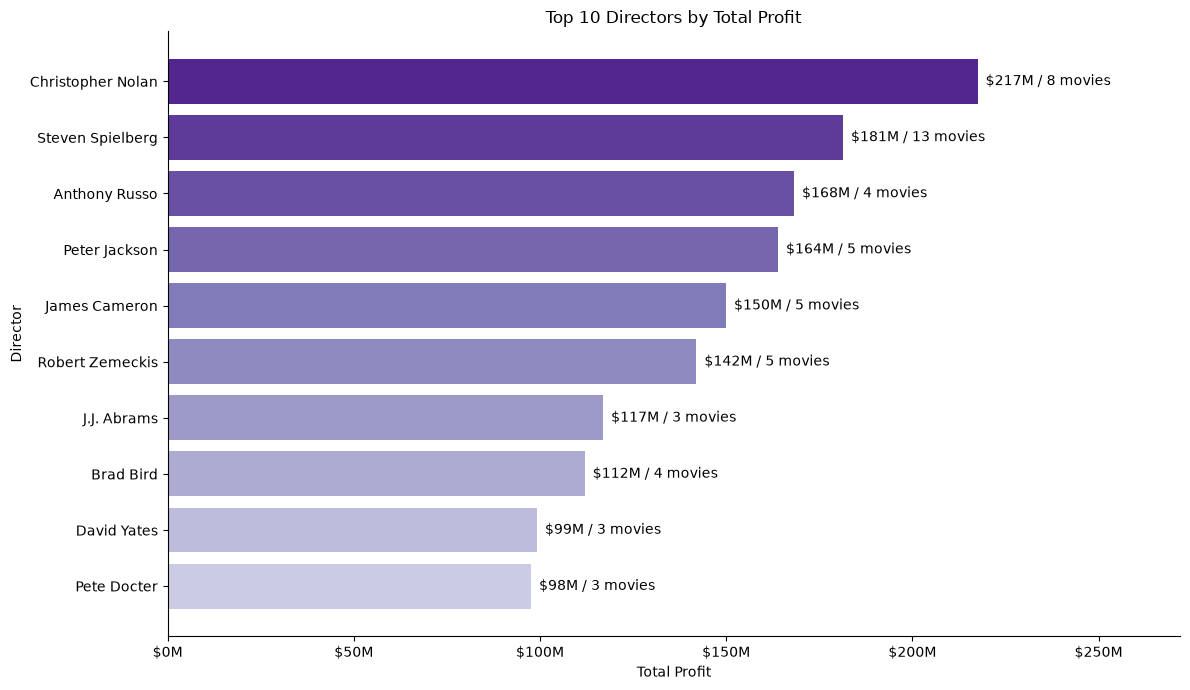

In [20]:
from matplotlib.ticker import FuncFormatter

plot_df = top_10_directors.sort_values("Directors_Total_Profit")

plt.figure(figsize=(12, 7))

colors = sns.color_palette(
    "Purples",
    n_colors=len(plot_df) + 5
)[4:]

bars = plt.barh(
    plot_df["Director"],
    plot_df["Directors_Total_Profit"],
    color=colors
)

def format_money(x):
    if x >= 1_000_000_000:
        return f"${x / 1_000_000_000:.1f}B"
    return f"${x / 1_000_000:.0f}M"

for bar, profit, movies in zip(
    bars,
    plot_df["Directors_Total_Profit"],
    plot_df["Movie_Count"]
):
    plt.text(
        bar.get_width() + plot_df["Directors_Total_Profit"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{format_money(profit)} / {movies} movies",
        va="center"
    )

plt.xlabel("Total Profit")
plt.ylabel("Director")
plt.title("Top 10 Directors by Total Profit")


ax = plt.gca()
ax.ticklabel_format(style="plain", axis="x")
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: format_money(x))
)

plt.xlim(
    0,
    plot_df["Directors_Total_Profit"].max() * 1.25
)

sns.despine()
plt.tight_layout()
plt.show()
plt.show()

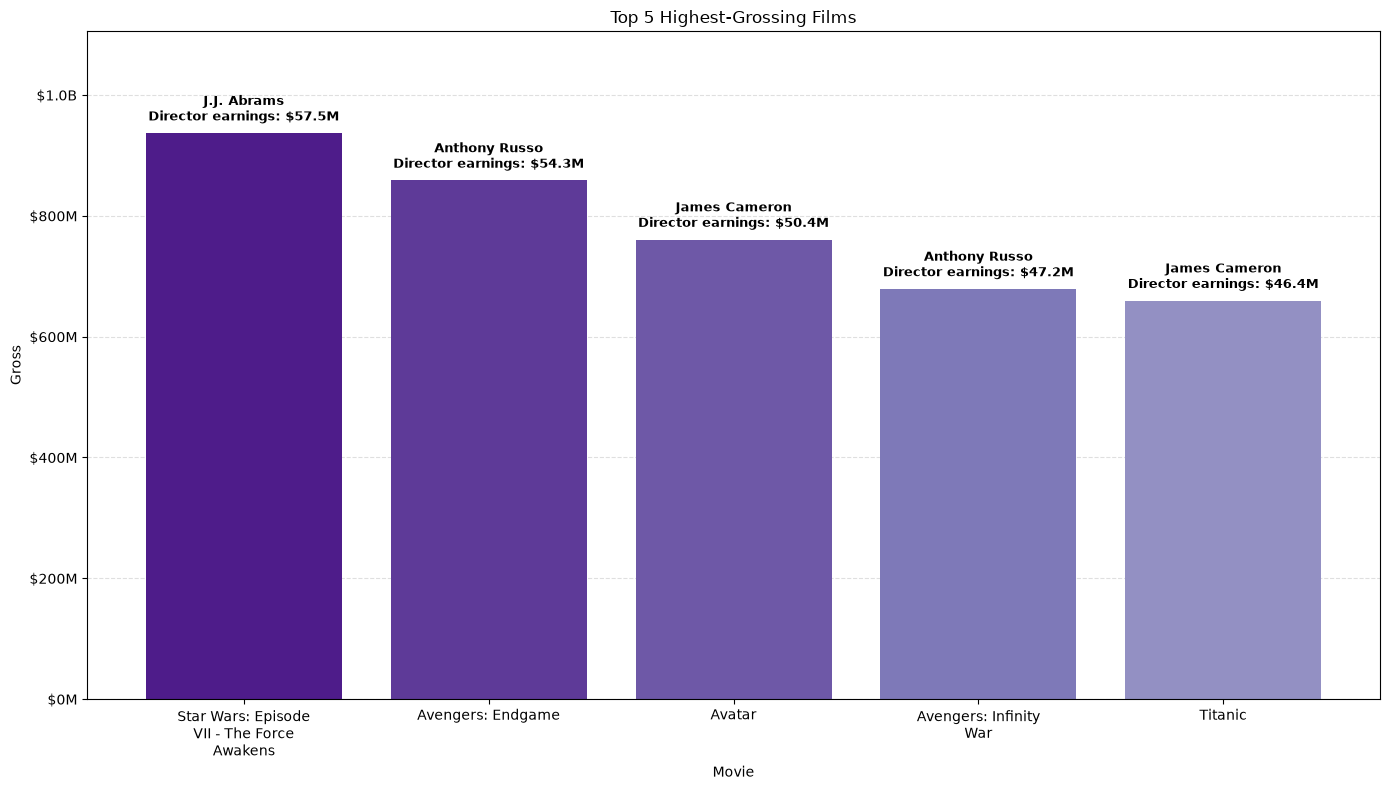

In [29]:
import matplotlib.ticker as mtick
import textwrap

top5 = dir_df.nlargest(5, "Gross").copy()

top5["director_profit"] = (
    top5["upfront_deal"] + top5["backend_profit"]
)

fig, ax = plt.subplots(figsize=(14, 8))

colors2 = sns.color_palette("Purples_r", n_colors=len(plot_df))

bars = ax.bar(
    top5["Series_Title"],
    top5["Gross"],
    color=colors2
)

# y axis numbers settings
def money_fmt(x, pos):
    return f"${x/1e9:.1f}B" if x >= 1e9 else f"${x/1e6:.0f}M"

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(money_fmt)
)

# Data labels
for bar, (_, row) in zip(bars, top5.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + top5["Gross"].max() * 0.015,
        f'{row["Director"]}\n'
        f'Director earnings: ${row["director_profit"]/1e6:.1f}M',
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

#x axis titles settings
labels = [
    "\n".join(textwrap.wrap(title, width=18))
    for title in top5["Series_Title"]
]

ax.set_xticks(range(len(top5)))
ax.set_xticklabels(labels, rotation=0, ha="center")

ax.set_xlabel("Movie")
ax.set_ylabel("Gross")
ax.set_title("Top 5 Highest-Grossing Films")

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Extra space for top labels
ax.set_ylim(0, top5["Gross"].max() * 1.18)

plt.tight_layout()
plt.show()

In [35]:
top_10_emerging = (
    dir_df[dir_df["director_profile"] == "Emerging"]
    .groupby("Director")
    .agg(
        Movie_Count=("Gross", "count"),
        Total_Gross=("Gross", "sum"),
        Average_Gross=("Gross", "mean"),
        Director_Earnings=("upfront_deal", "sum")
    )
    .reset_index()
)

backend = (
    dir_df[dir_df["director_profile"] == "Emerging"]
    .groupby("Director")["backend_profit"]
    .sum()
)

top_10_emerging["Director_Earnings"] += (
    top_10_emerging["Director"].map(backend).fillna(0)
)

top_10_emerging = (
    top_10_emerging
    .sort_values("Total_Gross", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_10_emerging["Total_Gross"] = top_10_emerging["Total_Gross"].map("${:,.0f}".format)
top_10_emerging["Average_Gross"] = top_10_emerging["Average_Gross"].map("${:,.0f}".format)
top_10_emerging["Director_Earnings"] = top_10_emerging["Director_Earnings"].map("${:,.0f}".format)

top_10_emerging

,Director,Movie_Count,Total_Gross,Average_Gross,Director_Earnings
0,Dean DeBlois,2,"$394,584,155","$197,292,078","$4,000,000"
1,Mike Newell,2,"$331,922,798","$165,961,399","$2,050,000"
2,Zack Snyder,2,"$318,124,738","$159,062,369","$4,000,000"
3,George Roy Hill,2,"$261,908,889","$130,954,444","$4,000,000"
4,William Friedkin,2,"$248,536,855","$124,268,428","$2,050,000"
5,Ethan Coen,2,"$245,526,630","$122,763,315","$3,000,000"
6,Gabriele Muccino,2,"$233,518,283","$116,759,142","$3,000,000"
7,Barry Levinson,2,"$227,900,000","$113,950,000","$2,050,000"
8,David O. Russell,2,"$225,709,967","$112,854,984","$3,000,000"
9,Doug Liman,2,"$221,867,939","$110,933,970","$4,000,000"


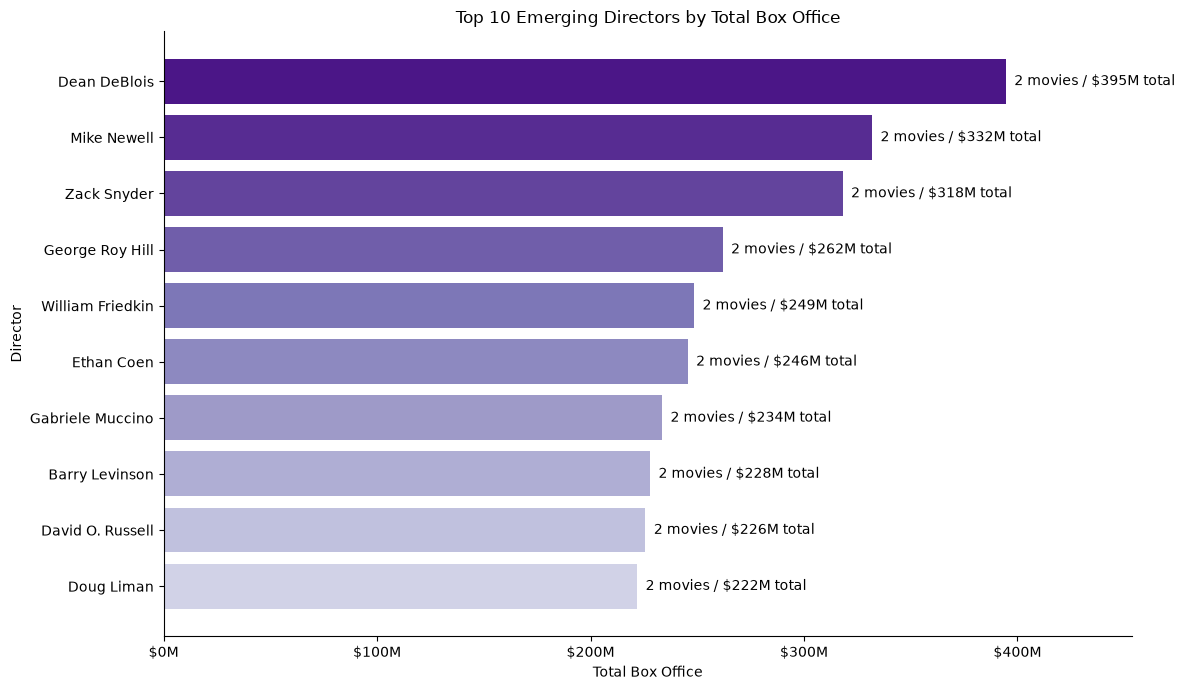

In [39]:
plot_df = (
    dir_df[dir_df["director_profile"] == "Emerging"]
    .groupby("Director")
    .agg(
        Movie_Count=("Gross", "count"),
        Total_Gross=("Gross", "sum")
    )
    .sort_values("Total_Gross")
    .tail(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

colors = sns.color_palette(
    "Purples",
    n_colors=len(plot_df) + 3
)[3:]

bars = plt.barh(
    plot_df["Director"],
    plot_df["Total_Gross"],
    color=colors
)

for bar, movies, total in zip(
    bars,
    plot_df["Movie_Count"],
    plot_df["Total_Gross"]
):
    plt.text(
        bar.get_width() + plot_df["Total_Gross"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{movies} movies / {format_money(total)} total",
        va="center"
    )

plt.xlabel("Total Box Office")
plt.ylabel("Director")
plt.title("Top 10 Emerging Directors by Total Box Office")

ax = plt.gca()

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: format_money(x))
)

plt.xlim(
    0,
    plot_df["Total_Gross"].max() * 1.15
)

sns.despine()
plt.tight_layout()
plt.show()